In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import pandas as pd
import os
import gc
import sys

sys.path.insert(0, '..')
from src import *

# NVE + NPT equilibration

## Velocity const

In [126]:
path = Filepaths.DATA.value / 'strains' / 'N4000' / 'T4.0_nve_npt' / 'dt0.001_eps0.005'
data = Data(path)
observ = data.read(['thermo', 'press'], dropdup=['timestep'])
thermo_data = data.read_df(['thermo'], dropdup=['timestep'])['thermo']
stress = observ['stress']

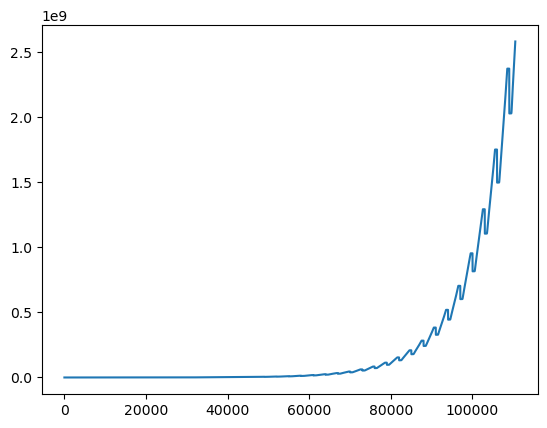

In [133]:
plt.plot(thermo_data.vol)

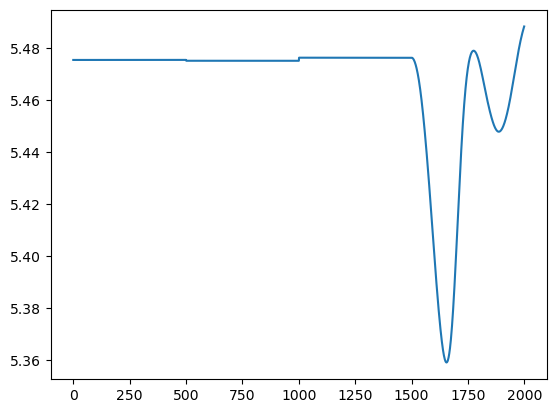

In [131]:
plt.plot(thermo_data.energy[:2000])

In [132]:
(thermo_data.vol[0] / 3800)**(1/3)

np.float64(2.1049293440025574)

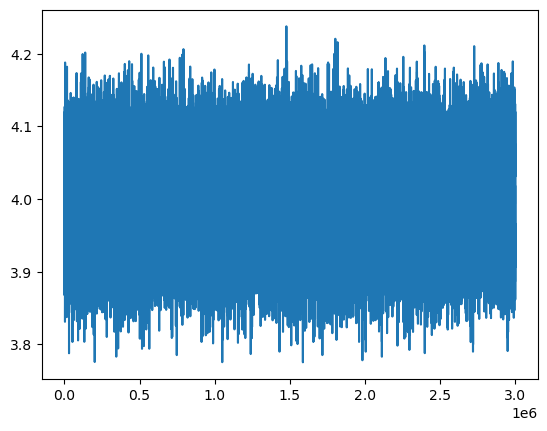

In [5]:
#plt.plot(sp.ndimage.gaussian_filter(thermo_data.temp, 1000))
plt.plot(thermo_data.temp)

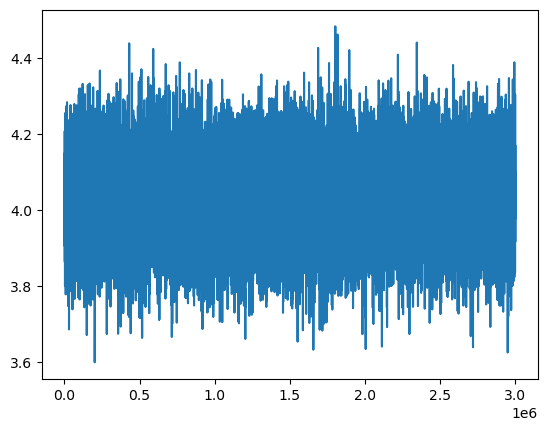

In [6]:
plt.plot(thermo_data.energy)

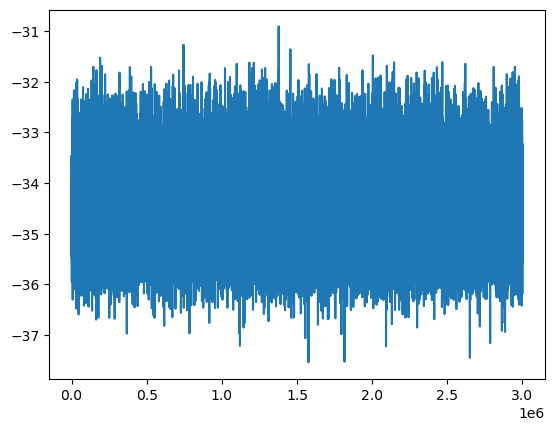

In [7]:
plt.plot(stress[:, 0, 0])

In [66]:
stress.shape

(3000501, 3, 3)

In [112]:
cycle_size = 3_000
num_cycles = 1000
stress_cycle = np.zeros(cycle_size)
energy_cycle = np.zeros_like(stress_cycle)
stress_avg = 0
for cycle in range(1, num_cycles):
    s0 = cycle * cycle_size
    s1 = (cycle + 1) * cycle_size
    stress_cycle += stress[s0:s1, 0, 0] / (num_cycles - 1)
    energy_cycle += np.array(thermo_data.energy)[s0:s1] / (num_cycles - 1)
    stress_avg += stress[s1-1000:s1, 0, 0].mean() / (num_cycles - 1)

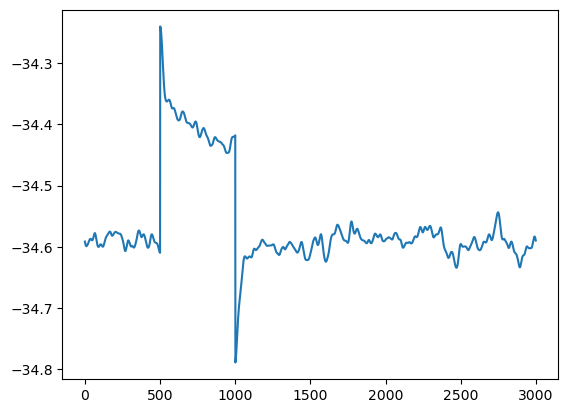

In [113]:
plt.plot(stress_cycle)

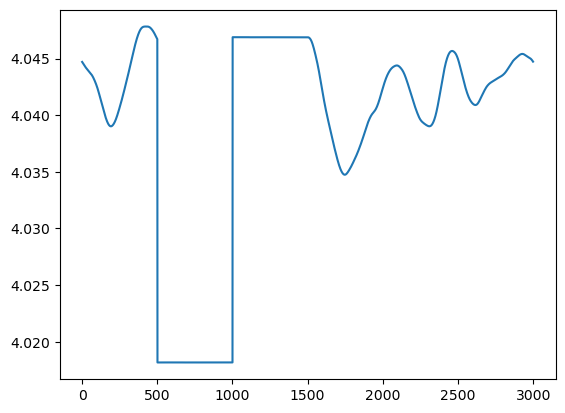

In [114]:
plt.plot(energy_cycle)

In [115]:
pmod = np.loadtxt(Filepaths.DATA.value / 'moduli_t' / 'pwave_dt0.0002')
dt = 0.0002
time_pmod = np.linspace(0, (len(pmod) - 1) * dt, len(pmod))

In [116]:
pmod_nl = np.loadtxt(Filepaths.DATA.value / 'moduli_t' / 'pwave_nonlin_dt0.005')
dt = 0.005
time_pmod_nl = np.linspace(0, (len(pmod_nl) - 1) * dt, len(pmod_nl))
pmod_nl_interp = np.interp(time_pmod, time_pmod_nl, pmod_nl)

In [117]:
bulk_qs = 186.7
e0 = stress_avg / bulk_qs
print(e0)

-0.18528232900870859


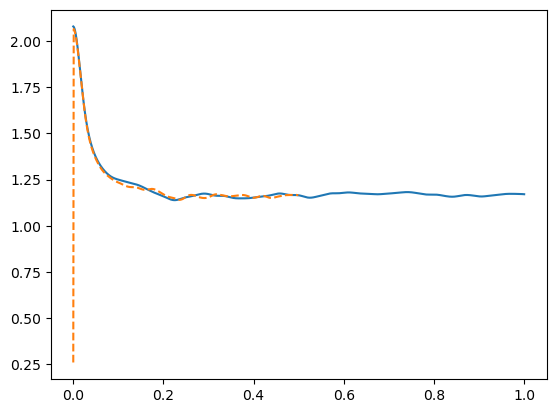

In [14]:
time = np.array(thermo_data.time[:500] - thermo_data.time[0])
#plt.plot(time, stress_cycle[500:1000] - stress_avg, label='numerical')
plt.plot(time_pmod, 0.005 * pmod, label='lin')
#plt.plot(time_pmod, 0.005 * pmod + 0.005**2 * pmod_nl_interp, label='lin+nonlin')
#plt.xlim(0, 0.4)
#plt.legend()
plt.plot(time, stress_cycle[500:1000] - stress_avg + 0.27, '--')

## Velocity remap

In [15]:
path = Filepaths.DATA.value / 'strains' / 'N4000' / 'T4.0_nve_nvt' / 'vel_remap_dt0.001'
data = Data(path)
observ = data.read(['thermo', 'press'], dropdup=['timestep'])
thermo_data = data.read_df(['thermo'], dropdup=['timestep'])['thermo']
V = observ['V']
T = observ['T']
stress = observ['stress']

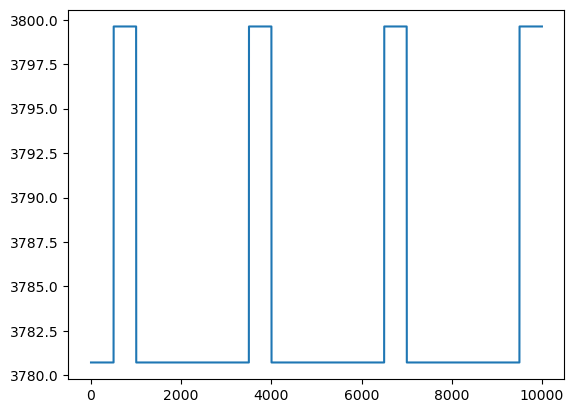

In [16]:
plt.plot(thermo_data.vol[:10000])

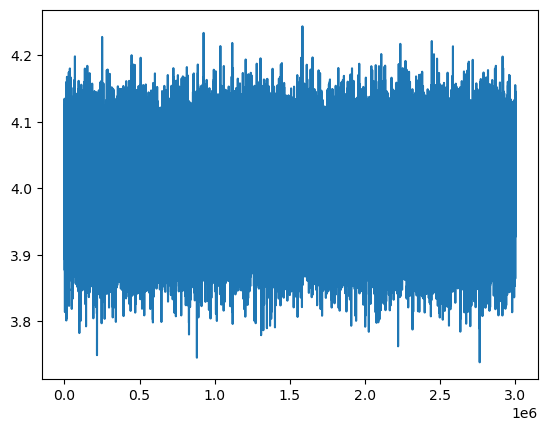

In [17]:
#plt.plot(sp.ndimage.gaussian_filter(thermo_data.temp, 1000))
plt.plot(thermo_data.temp)

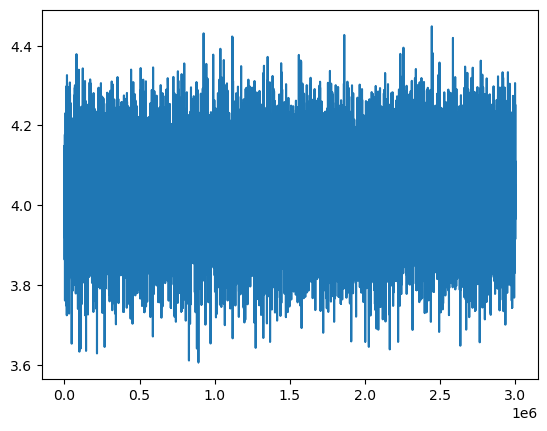

In [18]:
plt.plot(thermo_data.energy)

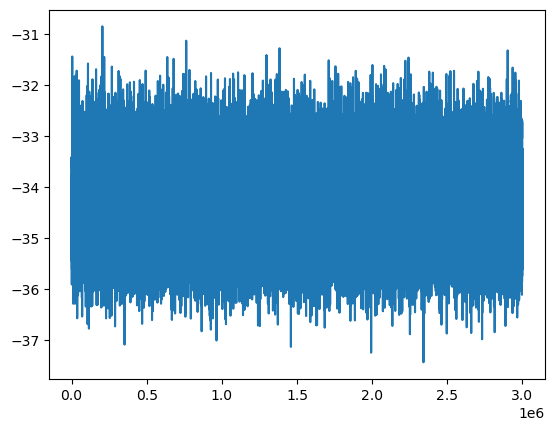

In [19]:
plt.plot(stress[:, 0, 0])

In [20]:
stress.shape

(3000501, 3, 3)

In [21]:
cycle_size = 3_000
num_cycles = 1000
stress_cycle_vr = np.zeros(cycle_size)
energy_cycle_vr = np.zeros(cycle_size)
stress_avg_vr = 0
for cycle in range(1, num_cycles):
    s0 = cycle * cycle_size
    s1 = (cycle + 1) * cycle_size
    stress_cycle_vr += stress[s0:s1, 0, 0] / (num_cycles - 1)
    energy_cycle_vr += np.array(thermo_data.energy)[s0:s1] / (num_cycles - 1)
    stress_avg_vr += stress[s1-1000:s1, 0, 0].mean() / (num_cycles - 1)

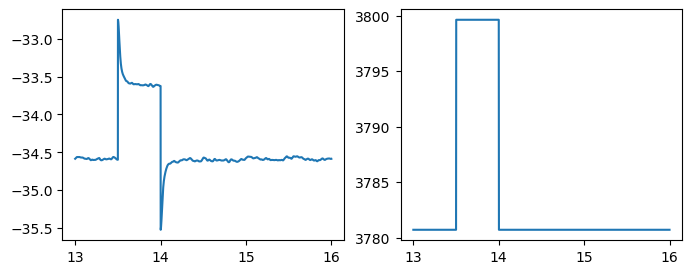

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(8,3))
ax[0].plot(thermo_data.time[cycle_size: 2*cycle_size], 
           stress_cycle_vr)
ax[1].plot(thermo_data.time[cycle_size: 2*cycle_size], 
           thermo_data.vol[cycle_size: 2*cycle_size])

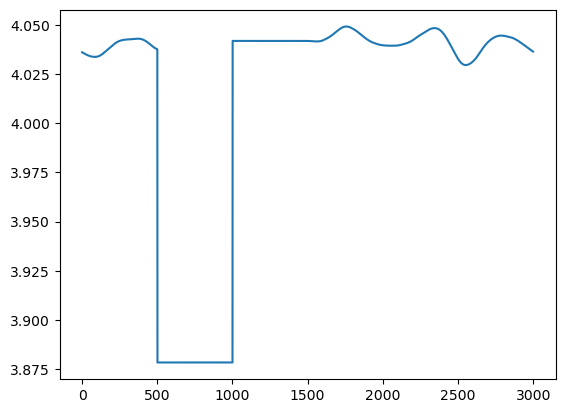

In [23]:
plt.plot(energy_cycle_vr)

In [24]:
pmod = np.loadtxt(Filepaths.DATA.value / 'moduli_t' / 'pwave_dt0.0002')
dt = 0.0002
time_pmod = np.linspace(0, (len(pmod) - 1) * dt, len(pmod))

In [25]:
pmod_nl = np.loadtxt(Filepaths.DATA.value / 'moduli_t' / 'pwave_nonlin_dt0.005')
dt = 0.005
time_pmod_nl = np.linspace(0, (len(pmod_nl) - 1) * dt, len(pmod_nl))
pmod_nl_interp = np.interp(time_pmod, time_pmod_nl, pmod_nl)

In [ ]:
# stress_cycle /= 1.005

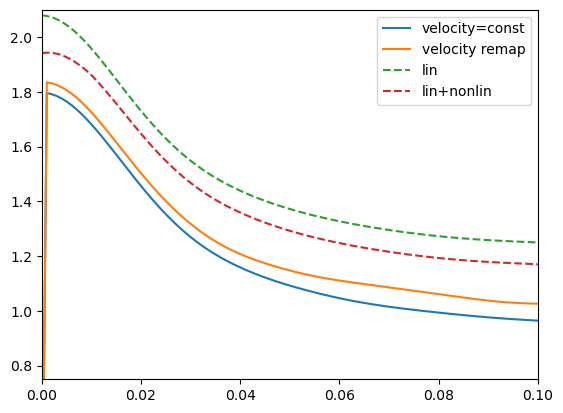

In [26]:
time = np.array(thermo_data.time[:500] - thermo_data.time[0])
plt.plot(time, stress_cycle[500:1000] - stress_avg, label='velocity=const')
plt.plot(time, stress_cycle_vr[500:1000] - stress_avg_vr, label='velocity remap')
plt.plot(time_pmod, 0.005 * pmod, '--', label='lin')
plt.plot(time_pmod, 0.005 * pmod + 0.005**2 * pmod_nl_interp, '--', label='lin+nonlin')
plt.xlim(0, 0.1)
plt.ylim(0.75,2.1)
plt.legend()
#plt.plot(time, stress_cycle_vr[500:1000] - stress_avg_vr + 0.05, '--')

(0.0, 0.1)

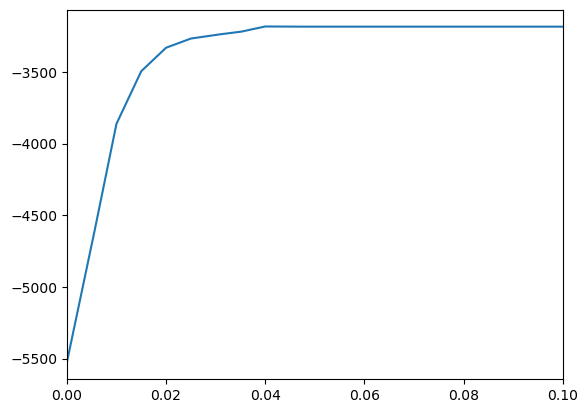

In [263]:
plt.plot(time_pmod, pmod_nl_interp)
plt.xlim(0, 0.1)

## Combined

In [ ]:
pmod = np.loadtxt(Filepaths.DATA.value / 'moduli_t' / 'pwave_dt0.0002')
dt = 0.0002
time_pmod = np.linspace(0, (len(pmod) - 1) * dt, len(pmod))

pmod_nl = np.loadtxt(Filepaths.DATA.value / 'moduli_t' / 'pwave_nonlin_dt0.005')
dt = 0.005
time_pmod_nl = np.linspace(0, (len(pmod_nl) - 1) * dt, len(pmod_nl))
pmod_nl_interp = np.interp(time_pmod, time_pmod_nl, pmod_nl)

In [57]:
print(data.path)

/home/fgarbuzov/Documents/lammps_test/data/strains/N4000/T4.0_nve_nvt/dt0.001_eps0.005


In [122]:
bulk_qs = 186.7

strains = [0.001, 0.005]
#strains = [0.005]
vel_remap = True

cycle_size = 3_000
num_cycles = 1000
stress_cycle = [np.zeros(cycle_size) for _ in range(len(strains))]

if vel_remap:
    stress_cycle_vr = [np.zeros(cycle_size) for _ in range(len(strains))]

base_path = Filepaths.DATA.value / 'strains' / 'N4000' / 'T4.0_nve_nvt'
for i, eps in enumerate(strains):
    data = Data(base_path / f'dt0.001_eps{eps}')
    print(data.path)
    observ = data.read(['thermo', 'press'], dropdup=['timestep'])
    thermo_data = data.read_df(['thermo'], dropdup=['timestep'])['thermo']
    stress = observ['stress']
    stress_avg = 0
    for cycle in range(1, num_cycles):
        s0 = cycle * cycle_size
        s1 = (cycle + 1) * cycle_size
        stress_cycle[i] += stress[s0:s1, 0, 0] / (num_cycles - 1)
        stress_avg += stress[s1-1000:s1, 0, 0].mean() / (num_cycles - 1)
    e0 = stress_avg / bulk_qs
    stress_cycle[i] -= stress_avg
    stress_cycle[i] /= 1 + e0

    if vel_remap:
        data = Data(base_path / f'vel_remap_dt0.001_eps{eps}')
        observ = data.read(['thermo', 'press'], dropdup=['timestep'])
        stress = observ['stress'].copy()
        stress_avg = 0
        for cycle in range(1, num_cycles):
            s0 = cycle * cycle_size
            s1 = (cycle + 1) * cycle_size
            stress_cycle_vr[i] += stress[s0:s1, 0, 0] / (num_cycles - 1)
            stress_avg += stress[s1-1000:s1, 0, 0].mean() / (num_cycles - 1)
        e0 = stress_avg / bulk_qs
        stress_cycle_vr[i] -= stress_avg
        stress_cycle_vr[i] /= 1 + e0

/home/fgarbuzov/Documents/lammps_test/data/strains/N4000/T4.0_nve_nvt/dt0.001_eps0.001
/home/fgarbuzov/Documents/lammps_test/data/strains/N4000/T4.0_nve_nvt/dt0.001_eps0.005


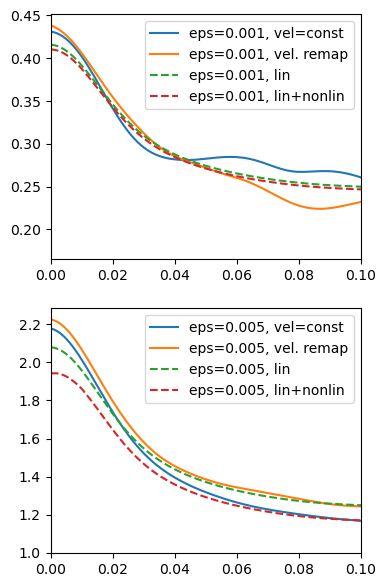

In [125]:
s0 = 501
s1 = 1001
time = np.array(thermo_data.time[:s1-s0] - thermo_data.time[0])
fig, axes = plt.subplots(len(strains), 1, figsize=(4, 4*len(strains)-1))
for i, (eps, ax) in enumerate(zip(strains, axes)):
    e0 = stress_cycle[i][s0] / bulk_qs
    #eps = eps + eps**2/2
    ax.plot(time, stress_cycle[i][s0:s1] / (1 + e0),
             label=f'eps={eps}, vel=const')
    if vel_remap:
        e0 = stress_cycle[i][s0] / bulk_qs
        ax.plot(time, stress_cycle_vr[i][s0:s1] / (1 + e0), 
                 label=f'eps={eps}, vel. remap')
    ax.plot(time_pmod, eps * pmod, '--', 
             label=f'eps={eps}, lin')
    ax.plot(time_pmod, eps * pmod + eps**2 * pmod_nl_interp, '--', 
             label=f'eps={eps}, lin+nonlin')
    ax.set_xlim(0, 0.1)
    ax.legend()
#axes[1].set_ylim(0.75,2.2)

In [88]:
stress_cycle[0][0]

np.float64(0.0007324475475982695)

In [90]:
stress_cycle[1][0]

np.float64(-0.001438575475404491)

# NVE + NVT equilibration

## Velocity const

In [77]:
path = Filepaths.DATA.value / 'strains' / 'N4000' / 'T4.0_nve_nvt' / 'dt0.001_eps0.001'
data = Data(path)
observ = data.read(['thermo', 'press'], dropdup=['timestep'])
thermo_data = data.read_df(['thermo'], dropdup=['timestep'])['thermo']
stress = observ['stress']

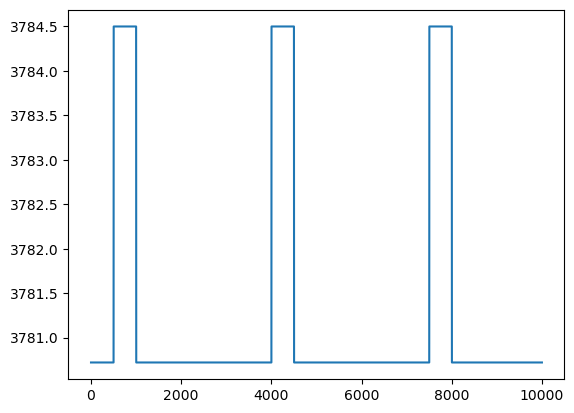

In [78]:
plt.plot(thermo_data.vol[:10000])

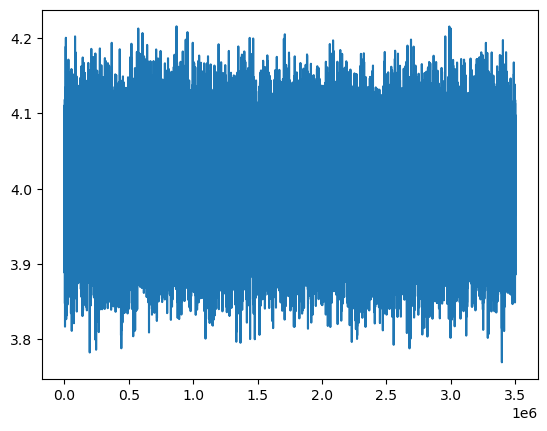

In [50]:
#plt.plot(sp.ndimage.gaussian_filter(thermo_data.temp, 1000))
plt.plot(thermo_data.temp)

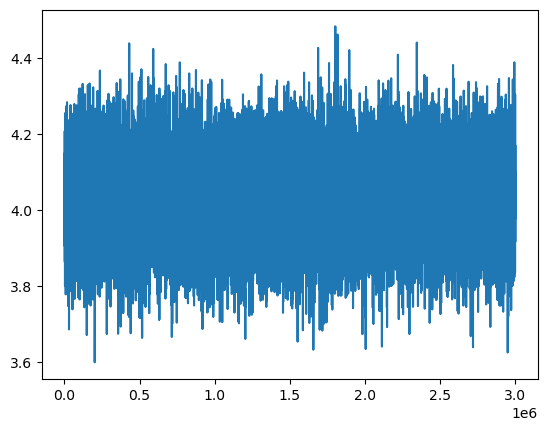

In [6]:
plt.plot(thermo_data.energy)

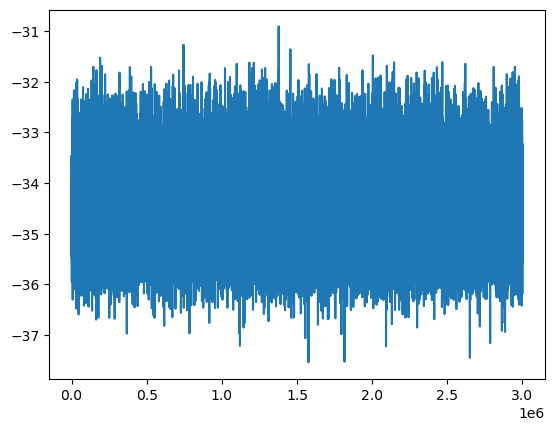

In [7]:
plt.plot(stress[:, 0, 0])

In [81]:
stress.shape

(7000001, 3, 3)

In [82]:
cycle_size = 3_500
num_cycles = 2000
stress_cycle = np.zeros(cycle_size)
energy_cycle = np.zeros_like(stress_cycle)
stress_avg = 0
for cycle in range(0, num_cycles):
    s0 = cycle * cycle_size
    s1 = (cycle + 1) * cycle_size
    stress_cycle += stress[s0:s1, 0, 0] / (num_cycles - 1)
    energy_cycle += np.array(thermo_data.energy)[s0:s1] / (num_cycles - 1)
    stress_avg += stress[s1-2000:s1, 0, 0].mean() / (num_cycles - 1)

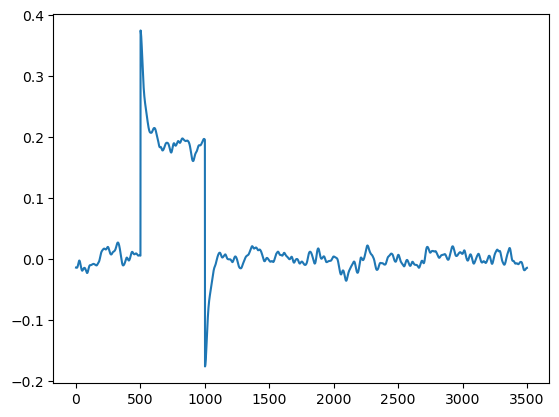

In [83]:
plt.plot(stress_cycle - stress_avg)

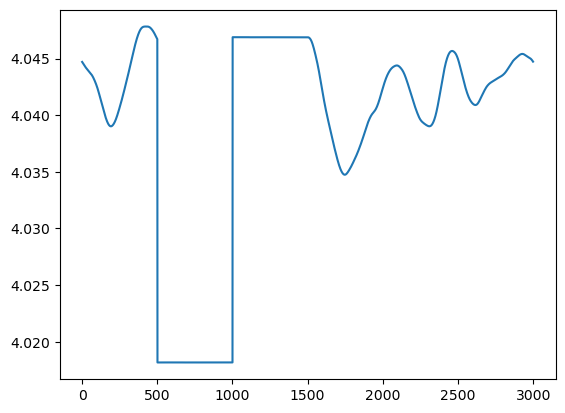

In [114]:
plt.plot(energy_cycle)

In [115]:
pmod = np.loadtxt(Filepaths.DATA.value / 'moduli_t' / 'pwave_dt0.0002')
dt = 0.0002
time_pmod = np.linspace(0, (len(pmod) - 1) * dt, len(pmod))

In [116]:
pmod_nl = np.loadtxt(Filepaths.DATA.value / 'moduli_t' / 'pwave_nonlin_dt0.005')
dt = 0.005
time_pmod_nl = np.linspace(0, (len(pmod_nl) - 1) * dt, len(pmod_nl))
pmod_nl_interp = np.interp(time_pmod, time_pmod_nl, pmod_nl)

In [117]:
bulk_qs = 186.7
e0 = stress_avg / bulk_qs
print(e0)

-0.18528232900870859


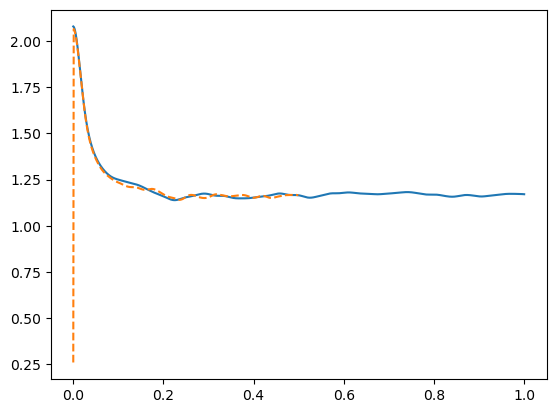

In [14]:
time = np.array(thermo_data.time[:500] - thermo_data.time[0])
#plt.plot(time, stress_cycle[500:1000] - stress_avg, label='numerical')
plt.plot(time_pmod, 0.005 * pmod, label='lin')
#plt.plot(time_pmod, 0.005 * pmod + 0.005**2 * pmod_nl_interp, label='lin+nonlin')
#plt.xlim(0, 0.4)
#plt.legend()
plt.plot(time, stress_cycle[500:1000] - stress_avg + 0.27, '--')

## Velocity remap

In [16]:
eps = 0.005
path = Filepaths.DATA.value / 'strains' / 'N4000' / 'T4.0_nve_nvt' / f'vel_remap_dt0.001_eps{eps}'
data = Data(path)
observ = data.read(['thermo', 'press'], dropdup=['timestep'])
thermo_data = data.read_df(['thermo'], dropdup=['timestep'])['thermo']
V = observ['V']
T = observ['T']
stress = observ['stress']

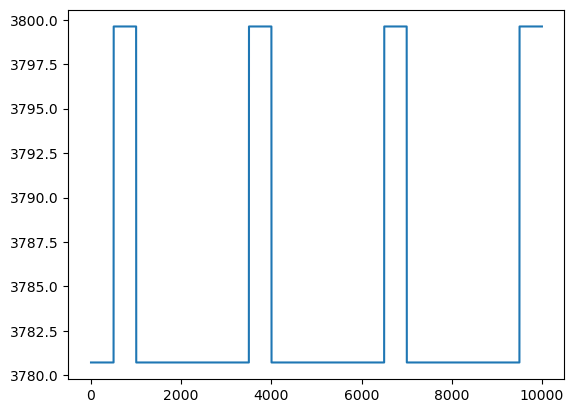

In [16]:
plt.plot(thermo_data.vol[:10000])

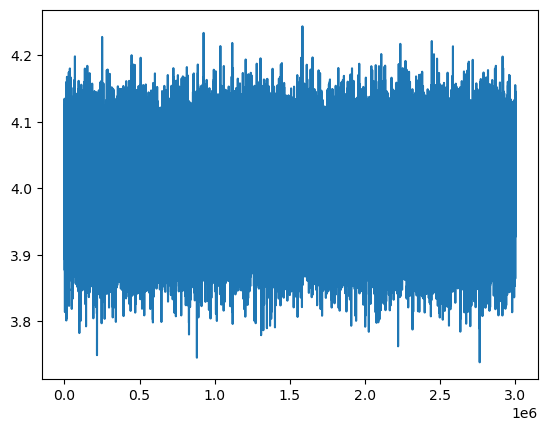

In [17]:
#plt.plot(sp.ndimage.gaussian_filter(thermo_data.temp, 1000))
plt.plot(thermo_data.temp)

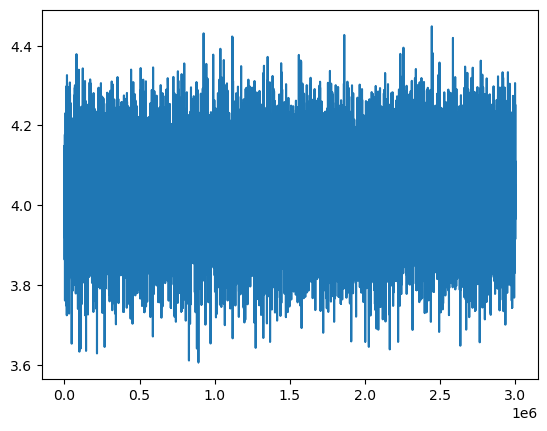

In [18]:
plt.plot(thermo_data.energy)

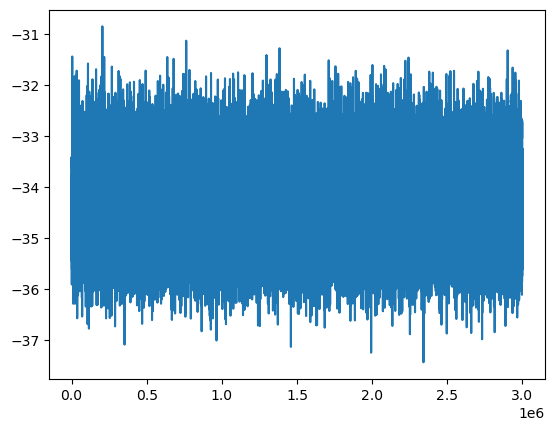

In [17]:
plt.plot(stress[:, 0, 0])

In [20]:
stress.shape

(3000501, 3, 3)

In [20]:
cycle_size = 3_000
num_cycles = 1000
stress_cycle_vr = np.zeros(cycle_size)
stress_yy_cycle_vr = np.zeros(cycle_size)
energy_cycle_vr = np.zeros(cycle_size)
stress_avg_vr = 0
for cycle in range(1, num_cycles):
    s0 = cycle * cycle_size
    s1 = (cycle + 1) * cycle_size
    stress_cycle_vr += stress[s0:s1, 0, 0] / (num_cycles - 1)
    stress_yy_cycle_vr += stress[s0:s1, 1, 1] / (num_cycles - 1)
    energy_cycle_vr += np.array(thermo_data.energy)[s0:s1] / (num_cycles - 1)
    stress_avg_vr += stress[s1-1000:s1, 0, 0].mean() / (num_cycles - 1)

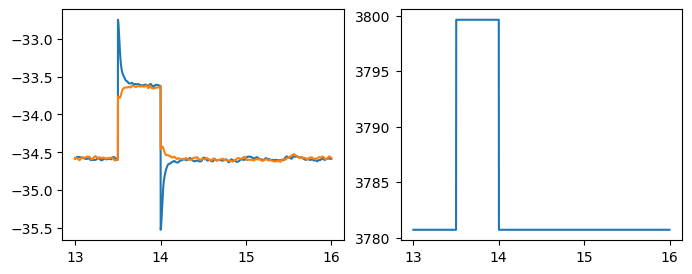

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(8,3))
ax[0].plot(thermo_data.time[cycle_size: 2*cycle_size], 
           stress_cycle_vr)
ax[0].plot(thermo_data.time[cycle_size: 2*cycle_size], 
           stress_yy_cycle_vr)
ax[1].plot(thermo_data.time[cycle_size: 2*cycle_size], 
           thermo_data.vol[cycle_size: 2*cycle_size])

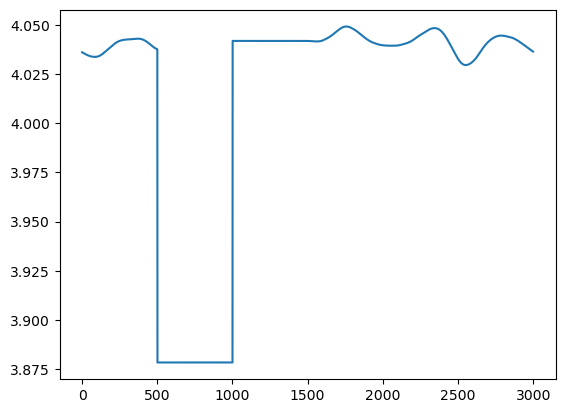

In [23]:
plt.plot(energy_cycle_vr)

In [24]:
pmod = np.loadtxt(Filepaths.DATA.value / 'moduli_t' / 'pwave_dt0.0002')
dt = 0.0002
time_pmod = np.linspace(0, (len(pmod) - 1) * dt, len(pmod))

In [25]:
pmod_nl = np.loadtxt(Filepaths.DATA.value / 'moduli_t' / 'pwave_nonlin_dt0.005')
dt = 0.005
time_pmod_nl = np.linspace(0, (len(pmod_nl) - 1) * dt, len(pmod_nl))
pmod_nl_interp = np.interp(time_pmod, time_pmod_nl, pmod_nl)

In [ ]:
# stress_cycle /= 1.005

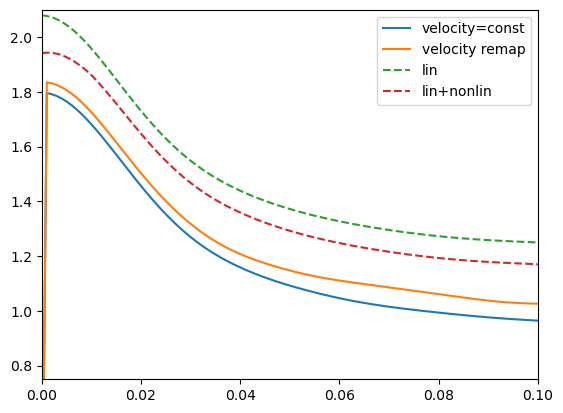

In [26]:
time = np.array(thermo_data.time[:500] - thermo_data.time[0])
plt.plot(time, stress_cycle[500:1000] - stress_avg, label='velocity=const')
plt.plot(time, stress_cycle_vr[500:1000] - stress_avg_vr, label='velocity remap')
plt.plot(time_pmod, 0.005 * pmod, '--', label='lin')
plt.plot(time_pmod, 0.005 * pmod + 0.005**2 * pmod_nl_interp, '--', label='lin+nonlin')
plt.xlim(0, 0.1)
plt.ylim(0.75,2.1)
plt.legend()
#plt.plot(time, stress_cycle_vr[500:1000] - stress_avg_vr + 0.05, '--')

(0.0, 0.1)

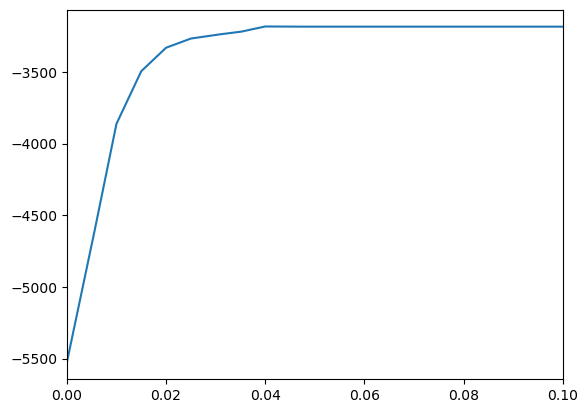

In [263]:
plt.plot(time_pmod, pmod_nl_interp)
plt.xlim(0, 0.1)

## Combined

In [2]:
pmod = np.loadtxt(Filepaths.DATA.value / 'moduli_t' / 'pwave_dt0.0002')
dt = 0.0002
time_pmod = np.linspace(0, (len(pmod) - 1) * dt, len(pmod))

pmod_nl = np.loadtxt(Filepaths.DATA.value / 'moduli_t' / 'pwave_nonlin_dt0.005')
dt = 0.005
time_pmod_nl = np.linspace(0, (len(pmod_nl) - 1) * dt, len(pmod_nl))
pmod_nl_interp = np.interp(time_pmod, time_pmod_nl, pmod_nl)

In [102]:
strains = [0.001, ]#0.002]#, 0.005]
#strains = [0.005]
vel_remap = False

cycle_size = 3_500
num_cycles = 8000
stress_cycle = [np.zeros(cycle_size) for _ in range(len(strains))]

if vel_remap:
    stress_cycle_vr = [np.zeros(cycle_size) for _ in range(len(strains))]

base_path = Filepaths.DATA.value / 'strains' / 'N4000' / 'T4.0_nve_nvt'
for i, eps in enumerate(strains):
    data = Data(base_path / f'dt0.001_eps{eps}')
    print(data.path)
    observ = data.read(['thermo', 'press'], dropdup=['timestep'])
    thermo_data = data.read_df(['thermo'], dropdup=['timestep'])['thermo']
    stress = observ['stress']
    stress_avg = 0
    for cycle in range(1, num_cycles):
        s0 = cycle * cycle_size
        s1 = (cycle + 1) * cycle_size
        stress_cycle[i] += stress[s0:s1, 0, 0] / (num_cycles - 1)
        stress_avg += stress[s1-1000:s1, 0, 0].mean() / (num_cycles - 1)
    stress_cycle[i] -= stress_avg
    stress_cycle[i] += (1 - 1/(1+eps)) * (-stress_avg)

    if vel_remap:
        data = Data(base_path / f'vel_remap_dt0.001_eps{eps}')
        observ = data.read(['thermo', 'press'], dropdup=['timestep'])
        stress = observ['stress'].copy()
        stress_avg = 0
        for cycle in range(1, num_cycles):
            s0 = cycle * cycle_size
            s1 = (cycle + 1) * cycle_size
            stress_cycle_vr[i] += stress[s0:s1, 0, 0] / (num_cycles - 1)
            stress_avg += stress[s1-1000:s1, 0, 0].mean() / (num_cycles - 1)
        stress_cycle_vr[i] -= stress_avg
        stress_cycle_vr[i] += (1 - 1/(1+eps)) * (-stress_avg)

/home/fgarbuzov/Documents/lammps_test/data/strains/N4000/T4.0_nve_nvt/dt0.001_eps0.001


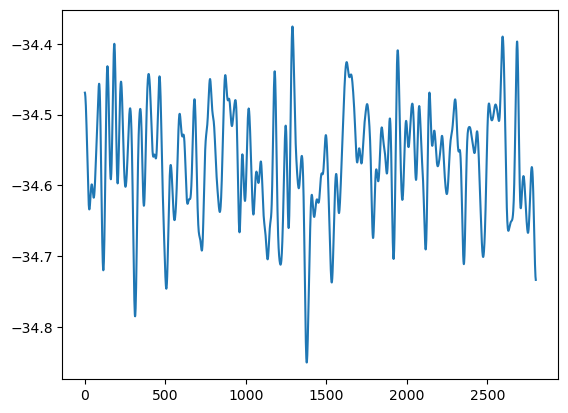

In [107]:
plt.plot(sp.ndimage.gaussian_filter(stress[::10000,0,0], 10))

In [90]:
path = Filepaths.DATA.value / 'strains' / 'N4000' / 'T4.0_nve_nvt' / 'dt0.001_eps0.001'
data = Data(path)
observ = data.read(['thermo', 'press'], dropdup=['timestep'])
thermo_data = data.read_df(['thermo'], dropdup=['timestep'])['thermo']
stress = observ['stress']

eps = strains[0]
cycle_size = 3_500
num_cycles = 2000
stress_cycle[0] = np.zeros(cycle_size)
stress_avg = 0
stress_cycle[i] += (1 - 1/(1+eps)) * (-stress_avg)
for cycle in range(0, num_cycles):
    s0 = cycle * cycle_size
    s1 = (cycle + 1) * cycle_size
    stress_cycle[0] += stress[s0:s1, 0, 0] / (num_cycles - 1)
    stress_avg += stress[s1-2000:s1, 0, 0].mean() / (num_cycles - 1)
stress_cycle[0] = stress_cycle[0][:3000] - stress_avg
stress_cycle[0] += (1 - 1/(1+eps)) * (-stress_avg)

In [91]:
path = Filepaths.DATA.value / 'strains' / 'N4000' / 'T4.0_nve_nvt' / 'dt0.001_eps0.002'
data = Data(path)
observ = data.read(['thermo', 'press'], dropdup=['timestep'])
thermo_data = data.read_df(['thermo'], dropdup=['timestep'])['thermo']
stress = observ['stress']

eps = strains[1]
cycle_size = 3_500
num_cycles = 1000
stress_cycle[1] = np.zeros(cycle_size)
stress_avg = 0
for cycle in range(0, num_cycles):
    s0 = cycle * cycle_size
    s1 = (cycle + 1) * cycle_size
    stress_cycle[1] += stress[s0:s1, 0, 0] / (num_cycles - 1)
    stress_avg += stress[s1-2000:s1, 0, 0].mean() / (num_cycles - 1)
stress_cycle[1] = stress_cycle[1][:3000] - stress_avg
stress_cycle[1] += (1 - 1/(1+eps)) * (-stress_avg)

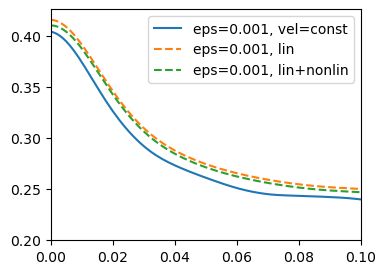

In [103]:
from collections.abc import Iterable
s0 = 501
s1 = 1001
time = np.array(thermo_data.time[:s1-s0] - thermo_data.time[0])
fig, axes = plt.subplots(len(strains), 1, figsize=(4, 4*len(strains)-1))
if not isinstance(axes, Iterable):
    axes = [axes]
for i, (eps, ax) in enumerate(zip(strains, axes)):
    #eps = eps + eps**2/2
    ax.plot(time, stress_cycle[i][s0:s1],
             label=f'eps={eps}, vel=const')
    if vel_remap:
        ax.plot(time, stress_cycle_vr[i][s0:s1], 
                 label=f'eps={eps}, vel. remap')
    ax.plot(time_pmod, eps * pmod, '--', 
             label=f'eps={eps}, lin')
    ax.plot(time_pmod, eps * pmod + eps**2 * pmod_nl_interp, '--', 
             label=f'eps={eps}, lin+nonlin')
    ax.set_xlim(0, 0.1)
    ax.legend()
#axes[1].set_ylim(0.75,2.2)

In [76]:
fig.savefig(Filepaths.DATA.value / 'sim_vs_theor.png')

In [62]:
0.001 * pmod[0] / stress_cycle[0][501]

np.float64(1.107090856594899)

In [63]:
0.002 * pmod[0] / stress_cycle[1][501]

np.float64(1.1508177960521164)

In [64]:
0.005 * pmod[0] / stress_cycle[2][501]

np.float64(1.0566176073580584)

# NVE

## Velocity const

In [109]:
path = Filepaths.DATA.value / 'strains' / 'N4000' / 'T4.0_nve' / 'dt0.001'
data = Data(path)
observ = data.read(['thermo', 'press'], dropdup=['timestep'])
thermo_data = data.read_df(['thermo'], dropdup=['timestep'])['thermo']
V = observ['V']
T = observ['T']
stress = observ['stress']

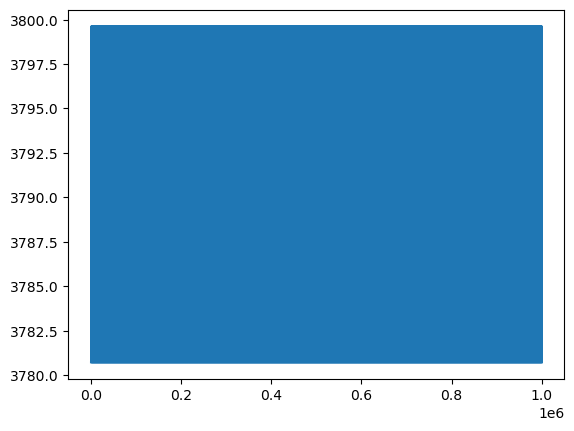

In [110]:
plt.plot(thermo_data.vol)

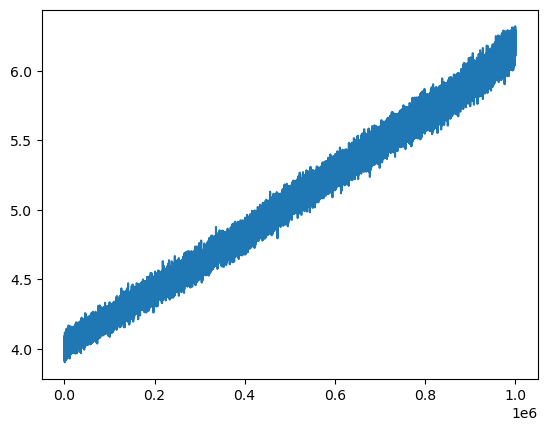

In [80]:
plt.plot(thermo_data.temp)

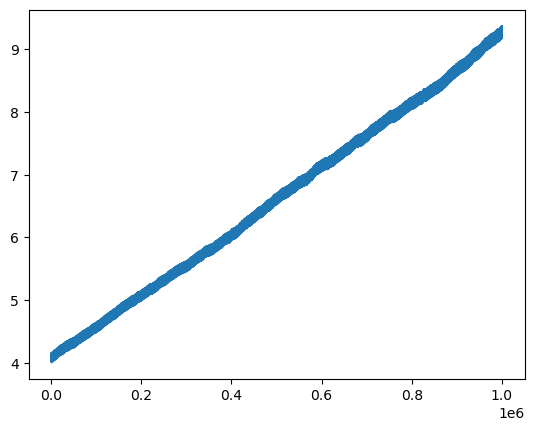

In [65]:
plt.plot(thermo_data.energy)

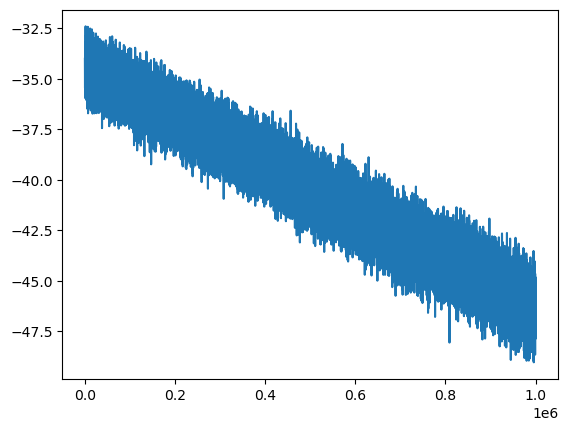

In [66]:
plt.plot(stress[:, 0, 0])

In [67]:
stress.shape

(1000501, 3, 3)

In [68]:
cycle_size = 1_000
num_cycles = 1_000
stress_cycle = np.zeros(cycle_size)
energy_cycle = np.zeros_like(stress_cycle)
for cycle in range(1, num_cycles):
    s0 = cycle * cycle_size
    s1 = (cycle + 1) * cycle_size
    stress_cycle += stress[s0:s1, 0, 0] / (num_cycles - 1)
    energy_cycle += np.array(thermo_data.energy)[s0:s1] / (num_cycles - 1)

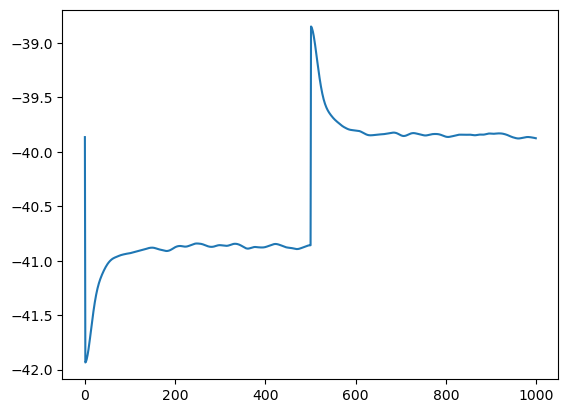

In [69]:
plt.plot(stress_cycle)

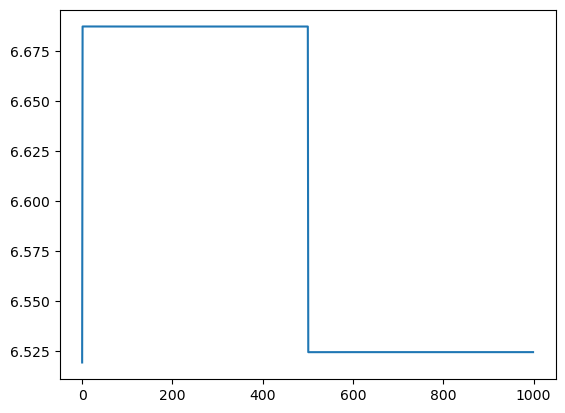

In [70]:
plt.plot(energy_cycle)

## Velocity remap

In [99]:
path = Filepaths.DATA.value / 'strains' / 'N4000' / 'T4.0_nve' / 'vel_remap_dt0.001'
data = Data(path)
observ = data.read(['thermo', 'press'], dropdup=['timestep'])
thermo_data = data.read_df(['thermo'], dropdup=['timestep'])['thermo']
V = observ['V']
T = observ['T']
stress = observ['stress']

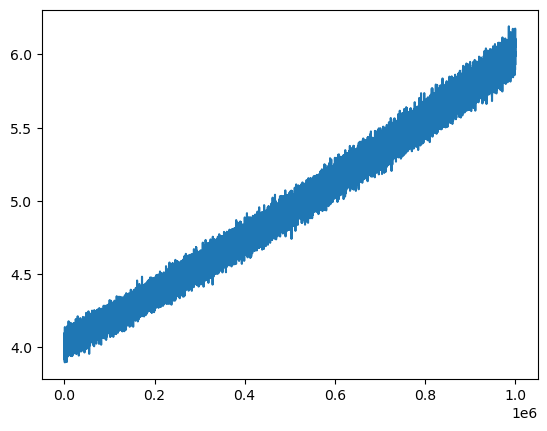

In [100]:
plt.plot(thermo_data.temp)

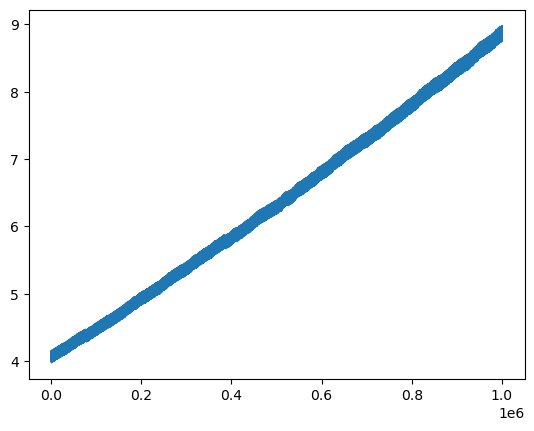

In [101]:
plt.plot(thermo_data.energy)

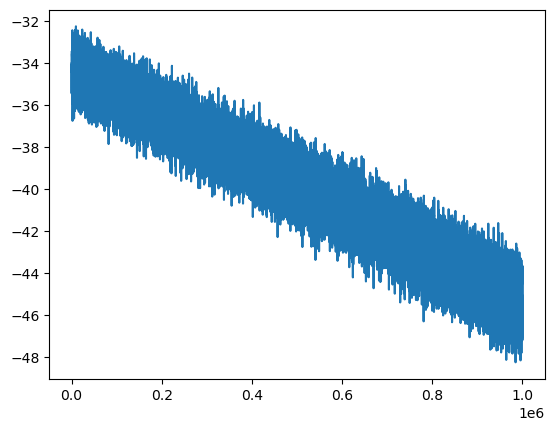

In [102]:
plt.plot(stress[:, 0, 0])

In [103]:
stress.shape

(1000501, 3, 3)

In [111]:
cycle_size = 1_000
num_cycles = 1_000
stress_cycle_vr = np.zeros(cycle_size)
energy_cycle_vr = np.zeros_like(stress_cycle_vr)
temp_cycle_vr = np.zeros_like(stress_cycle_vr)
vol_cycle_vr = np.zeros_like(stress_cycle_vr)
for cycle in range(1, num_cycles):
    s0 = cycle * cycle_size
    s1 = (cycle + 1) * cycle_size
    stress_cycle_vr += stress[s0:s1, 0, 0] / (num_cycles - 1)
    energy_cycle_vr += np.array(thermo_data.energy)[s0:s1] / (num_cycles - 1)
    temp_cycle_vr += np.array(thermo_data.temp)[s0:s1] / (num_cycles - 1)
    vol_cycle_vr += np.array(thermo_data.vol)[s0:s1] / (num_cycles - 1)

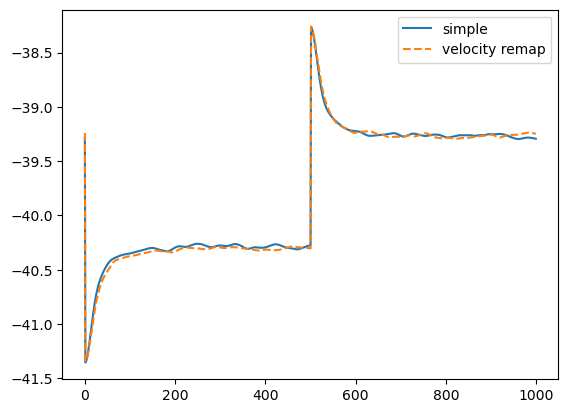

In [105]:
plt.plot(stress_cycle + 0.58, label='simple')
plt.plot(stress_cycle_vr, '--', label='velocity remap')
plt.legend()

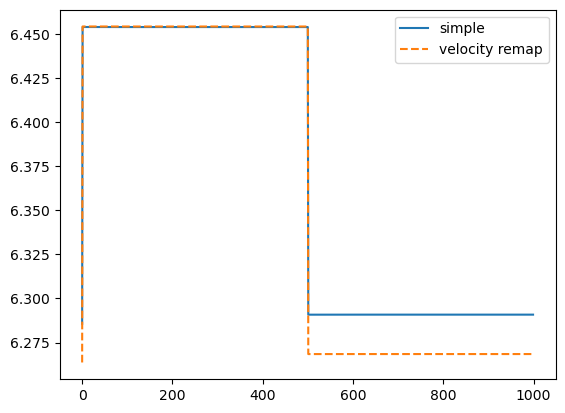

In [106]:
plt.plot(energy_cycle - 0.2335, label='simple')
plt.plot(energy_cycle_vr, '--', label='velocity remap')
#plt.ylim(0,7)
plt.legend()

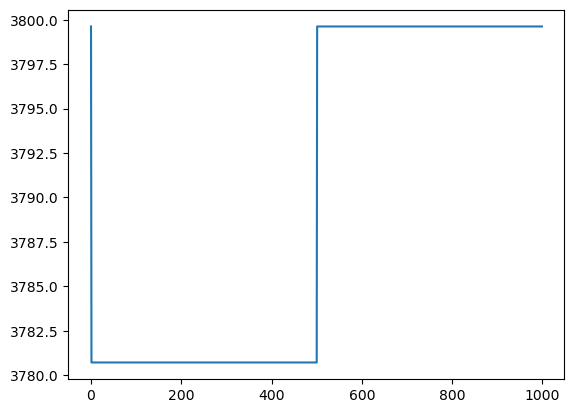

In [112]:
plt.plot(vol_cycle_vr)

# NVT

In [113]:
path = Filepaths.DATA.value / 'strains' / 'N4000' / 'T4.0_nvt' / 'dt0.001'
data = Data(path)
observ = data.read(['thermo', 'press'], dropdup=['timestep'])
thermo_data = data.read_df(['thermo'], dropdup=['timestep'])['thermo']
V = observ['V']
T = observ['T']
stress = observ['stress']

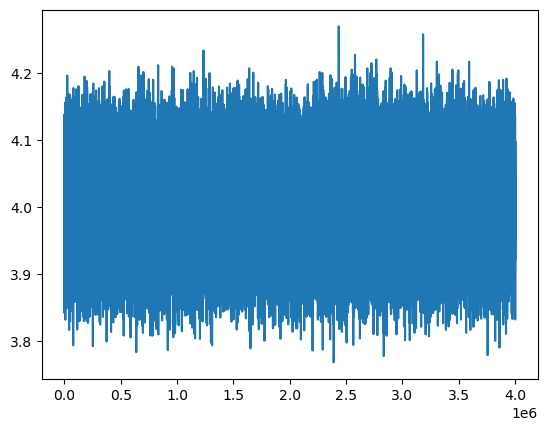

In [114]:
plt.plot(thermo_data.temp)

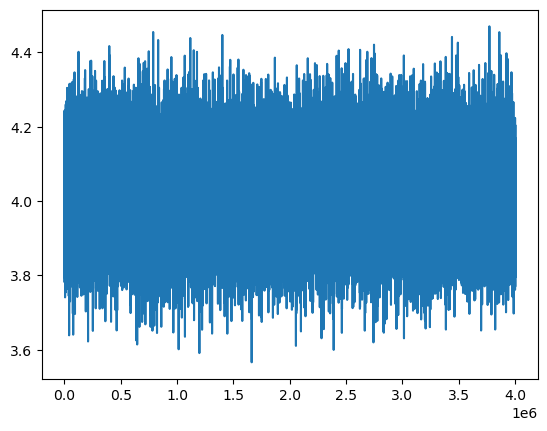

In [115]:
plt.plot(thermo_data.energy)

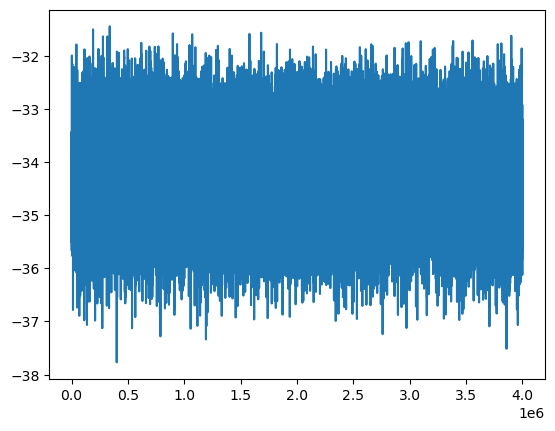

In [116]:
plt.plot(stress[:, 0, 0])

In [117]:
stress.shape

(4002001, 3, 3)

In [118]:
cycle_size = 4_000
num_cycles = 1_000
stress_cycle_nvt = np.zeros(cycle_size)
energy_cycle_nvt = np.zeros_like(stress_cycle_nvt)
for cycle in range(1, num_cycles):
    s0 = cycle * cycle_size
    s1 = (cycle + 1) * cycle_size
    stress_cycle_nvt += stress[s0:s1, 0, 0] / (num_cycles - 1)
    energy_cycle_nvt += np.array(thermo_data.energy)[s0:s1] / (num_cycles - 1)

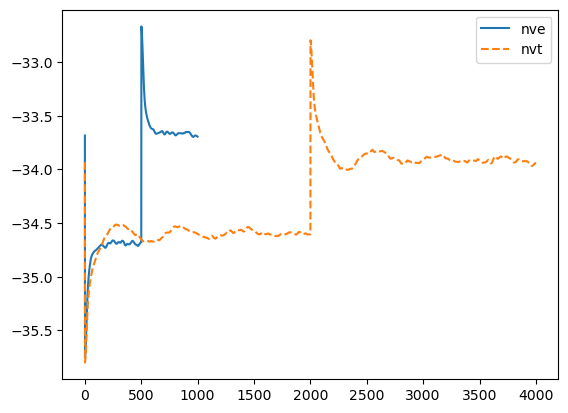

In [119]:
plt.plot(stress_cycle + 6.18, label='nve')
plt.plot(stress_cycle_nvt, '--', label='nvt')
plt.legend()

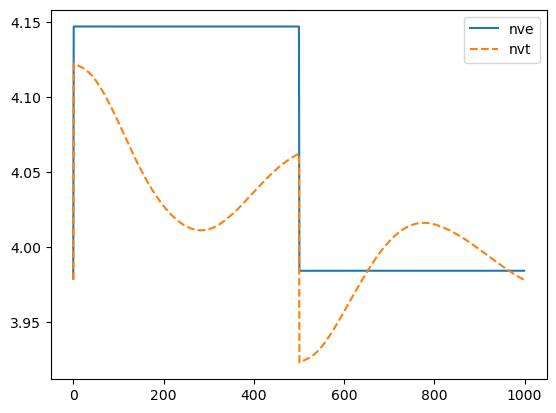

In [98]:
plt.plot(energy_cycle - 2.54, label='nve')
plt.plot(energy_cycle_nvt, '--', label='nvt')
#plt.ylim(0,7)
plt.legend()